In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

users = pd.read_csv(r'C:\Users\nanda\OneDrive\Desktop\Flam Project\users.csv')
campaigns = pd.read_csv(r'C:\Users\nanda\OneDrive\Desktop\Flam Project\campaigns.csv')
usage = pd.read_csv(r'C:\Users\nanda\OneDrive\Desktop\Flam Project\usage_metrics.csv')

print(users.head())
print(campaigns.head())
print(usage.head())

users.drop_duplicates(inplace=True)
campaigns.drop_duplicates(inplace=True)
usage.drop_duplicates(inplace=True)

users.fillna({'country': 'Unknown', 'device_type': 'Unknown'}, inplace=True)
campaigns.fillna({'experience_type': 'Unknown', 'credits_used': 0, 'engagement_score': 0}, inplace=True)
usage.fillna(0, inplace=True)

users.to_csv(r'C:\Users\nanda\OneDrive\Desktop\Flam Project\users_cleaned.csv', index=False)
campaigns.to_csv(r'C:\Users\nanda\OneDrive\Desktop\Flam Project\campaigns_cleaned.csv', index=False)
usage.to_csv(r'C:\Users\nanda\OneDrive\Desktop\Flam Project\usage_cleaned.csv', index=False)

print("✅ Cleaned datasets saved successfully!")

  user_id signup_date  country   device referral_code
0   U0001  2025-09-12  Germany      iOS           NaN
1   U0002  2025-08-23  Germany      iOS            No
2   U0003  2025-09-15      USA  Android            No
3   U0004  2025-08-12    India  Android            No
4   U0005  2025-09-14  Germany      iOS           NaN
  campaign_id user_id      experience_type     status  credits_used  \
0      C00001   U0002                  NaN      draft           NaN   
1      C00002   U0002                  NaN  published           4.0   
2      C00003   U0003                Alpha  published           5.0   
3      C00004   U0004  Spatial Interactive  published           1.0   
4      C00005   U0004    Prism Interactive  published           1.0   

  created_date published_date  
0   2025-09-17            NaN  
1   2025-09-07     2025-09-12  
2   2025-10-02     2025-10-04  
3   2025-08-31     2025-09-17  
4   2025-08-26     2025-08-28  
  user_id week_start_date  sessions  avg_session_time  en

        experience_type  Total_Campaigns  Publish_Rate  Avg_Credits_Used
0         3D Experience               36         47.22          1.777778
1            3D Spatial               51         50.98          1.450980
2                 Alpha               41         43.90          1.463415
3     Alpha Interactive               29         37.93          1.241379
4                 Prism               42         47.62          1.071429
5        Prism Extended               50         28.00          0.940000
6     Prism Interactive               45         48.89          1.044444
7         Spatial Alpha               43         34.88          0.837209
8   Spatial Interactive               37         48.65          1.648649
9            Spatial TV               41         48.78          1.243902
10              Unknown               15         40.00          1.000000


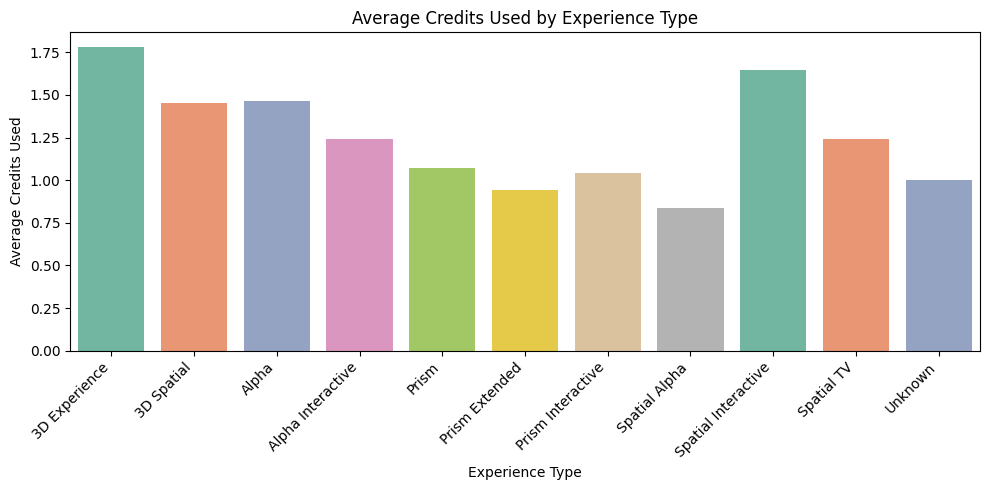

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


campaigns['is_published'] = campaigns['status'].str.lower() == 'published'


merged = campaigns.merge(users, on='user_id', how='left')
merged_usage = usage.merge(users, on='user_id', how='left')


exp_summary = (merged.groupby('experience_type')
    .agg(
        Total_Campaigns=('campaign_id', 'count'),
        Publish_Rate=('is_published', 'mean'),
        Avg_Credits_Used=('credits_used', 'mean')
    )
    .reset_index()
)


exp_summary['Publish_Rate'] = (exp_summary['Publish_Rate'] * 100).round(2)


print(exp_summary)

plt.figure(figsize=(10, 5))
sns.barplot(x='experience_type', y='Avg_Credits_Used',hue='experience_type',data=exp_summary,legend='auto',palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title("Average Credits Used by Experience Type")
plt.xlabel("Experience Type")
plt.ylabel("Average Credits Used")
plt.tight_layout()
plt.show()

In [20]:
ref_summary = merged.groupby('referral_code').agg({
    'user_id': 'count',
    'campaign_id': 'count',
    'is_published': 'mean'
}).rename(columns={
    'user_id': 'Users',
    'campaign_id': 'Campaigns',
    'is_published': 'Publish_Rate'
}).reset_index()

print(ref_summary)

  referral_code  Users  Campaigns  Publish_Rate
0            No    270        270      0.470370
1           Yes    136        136      0.382353


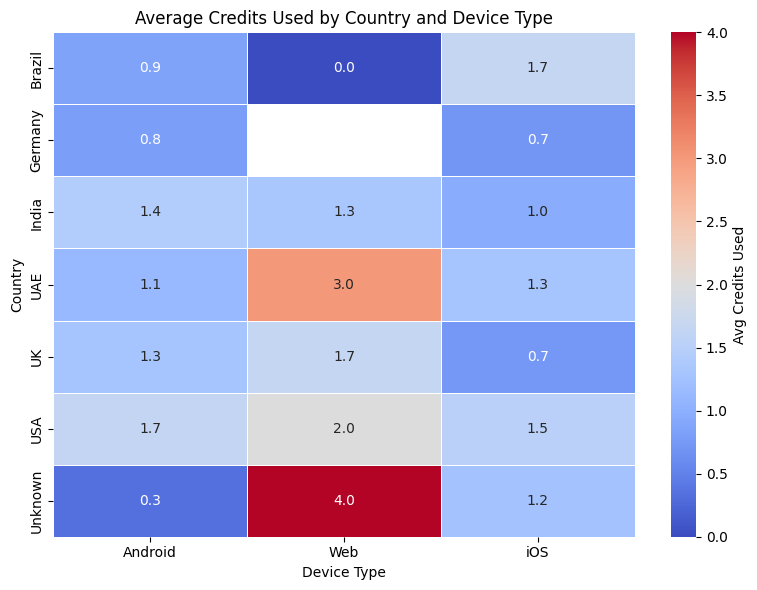

In [22]:
pivot = merged.pivot_table(
    values='credits_used',
    index='country',
    columns='device',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot,
    cmap='coolwarm',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Avg Credits Used'}
)
plt.title("Average Credits Used by Country and Device Type")
plt.xlabel("Device Type")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

✅ Logistic Regression Results:
Accuracy: 0.97

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        73
           1       1.00      0.93      0.96        56

    accuracy                           0.97       129
   macro avg       0.97      0.96      0.97       129
weighted avg       0.97      0.97      0.97       129



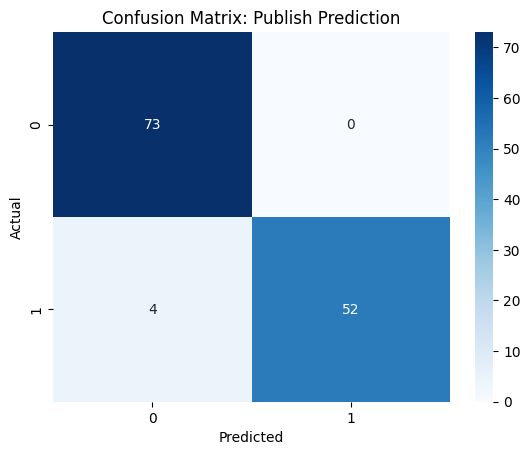

In [25]:
df = merged.copy()
df = df.dropna(subset=['is_published'])

# Features (only if available in your data)
features = ['credits_used', 'experience_type', 'country', 'device_type']
features = [f for f in features if f in df.columns]

encoded = df[features + ['is_published']].copy()
for col in encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    encoded[col] = le.fit_transform(encoded[col].astype(str))

X = encoded.drop('is_published', axis=1)
y = encoded['is_published'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("✅ Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Publish Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()